#### Import Libraries

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import Birch
import seaborn as sns
from collections import Counter

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from sklearn.metrics import silhouette_score

#### Import Datasets

In [9]:
%store -r X_cluster_Scaled
%store -r y
%store -r X_x

X = X_x[["Type", "Rotational speed [rpm]", "Torque [Nm]", "Air temperature [K]", "Process temperature [K]", "Tool wear [min]"]]
X = pd.DataFrame(X) 

In [10]:
n_clusters_list = range(2, 10)  
silhouette_list = []
  
if 'BIRCH_Cluster' in X.columns:
    X.drop(columns=['BIRCH_Cluster'], inplace=True)

for n in n_clusters_list:
    birch_model = Birch(n_clusters=n)
    labels = birch_model.fit_predict(X)
    
    if len(set(labels)) > 1: 
        silhouette_avg = silhouette_score(X, labels)
        silhouette_list.append(silhouette_avg)
    else:
        silhouette_list.append(-1) 

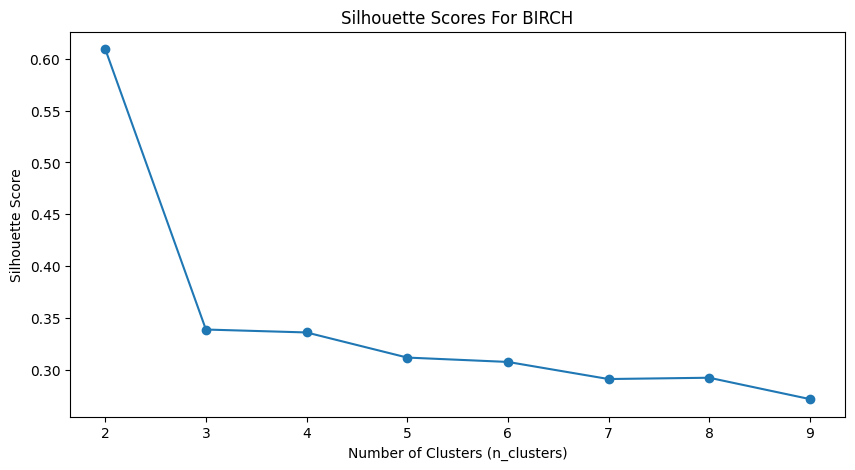

In [11]:
# Plot the silhouette scores
plt.figure(figsize=(10, 5))
plt.plot(n_clusters_list, silhouette_list, marker='o')
plt.title("Silhouette Scores For BIRCH")
plt.xlabel("Number of Clusters (n_clusters)")
plt.ylabel("Silhouette Score")
plt.show()

In [12]:
birch_model = Birch(n_clusters=3)
labels = birch_model.fit_predict(X)

X['BIRCH_Cluster'] = labels

cluster_counts_birch = Counter(X['BIRCH_Cluster'])
print("Number of samples in each BIRCH cluster:")
for cluster, count in cluster_counts_birch.items():
    print(f"Cluster {cluster}: {count} samples")

silhouette_avg = silhouette_score(X.drop(columns=['BIRCH_Cluster']), labels)
print(f"\nSilhouette Score for birch: {silhouette_avg}")

Number of samples in each BIRCH cluster:
Cluster 1: 4535 samples
Cluster 2: 4554 samples
Cluster 0: 893 samples

Silhouette Score for birch: 0.33867213832153575


In [13]:
if len(X_x) == len(y):
    X_x['KMeans_Cluster'] = birch_model.fit_predict(X_x)

    combined_df = pd.concat([X_x, y.reset_index(drop=True)], axis=1)

    cluster_distribution = combined_df.groupby(['Failure Type', 'KMeans_Cluster']).size().reset_index(name='Count')
    
    print(cluster_distribution)
else:
    print(f"Mismatch in lengths: X_test_Scaled has {len(X_x)} rows, but y_test has {len(y)} rows.")

    Failure Type  KMeans_Cluster  Count
0            0.0             0.0     10
1            0.0             1.0     58
2            0.0             2.0     44
3            1.0             0.0    860
4            1.0             1.0   4356
5            1.0             2.0   4418
6            2.0             0.0      6
7            2.0             1.0     43
8            2.0             2.0     29
9            3.0             0.0     13
10           3.0             1.0     33
11           3.0             2.0     49
12           4.0             0.0      2
13           4.0             1.0     33
14           4.0             2.0     10


#### Silhouette Coefficient

In [14]:
silhouette_avg = silhouette_score(X.drop(columns=['BIRCH_Cluster']), labels)
print(f"\nSilhouette Score for birch: {silhouette_avg}")


Silhouette Score for birch: 0.33867213832153575


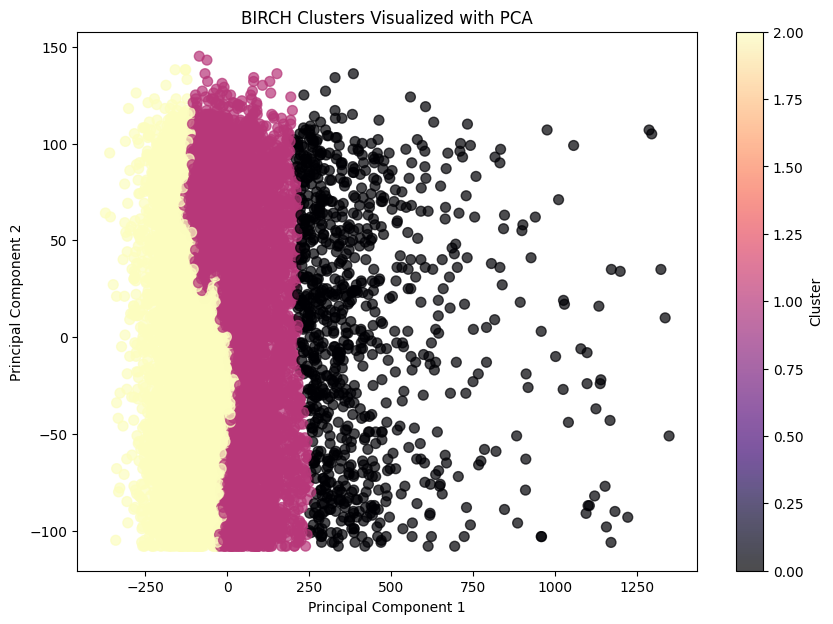

In [15]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.drop(columns=['BIRCH_Cluster'], errors='ignore'))

plt.figure(figsize=(10, 7))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='magma', s=50, alpha=0.7)
plt.colorbar(label='Cluster')
plt.title("BIRCH Clusters Visualized with PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

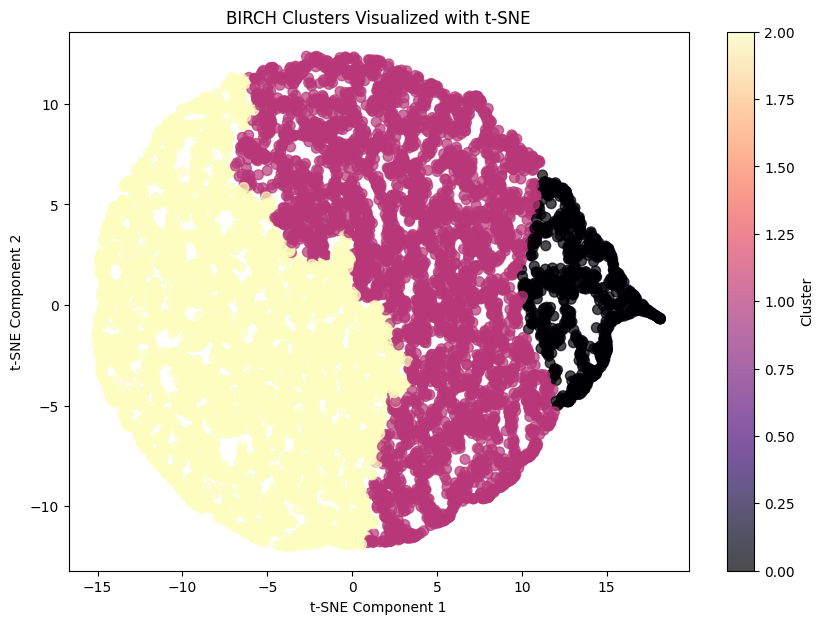

In [16]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, n_iter=300, random_state=42)
X_tsne = tsne.fit_transform(X.drop(columns=['BIRCH_Cluster'], errors='ignore'))

# Plot the clusters
plt.figure(figsize=(10, 7))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='magma', s=50, alpha=0.7)
plt.colorbar(label='Cluster')
plt.title("BIRCH Clusters Visualized with t-SNE")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.show()


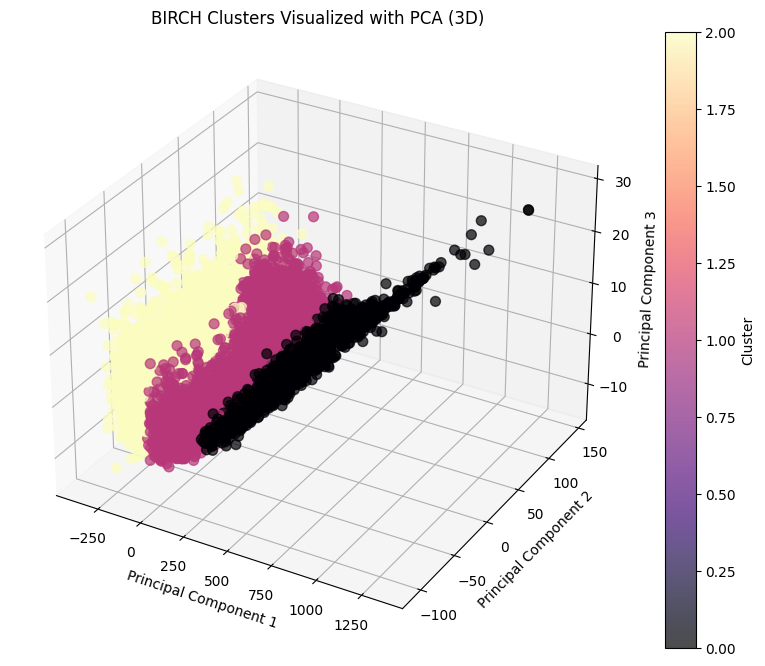

In [17]:
pca = PCA(n_components=3)
X_pca_3d = pca.fit_transform(X.drop(columns=['BIRCH_Cluster'], errors='ignore'))

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2],
                      c=labels, cmap='magma', s=50, alpha=0.7)

ax.set_title("BIRCH Clusters Visualized with PCA (3D)")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")
fig.colorbar(scatter, label='Cluster')
plt.show()

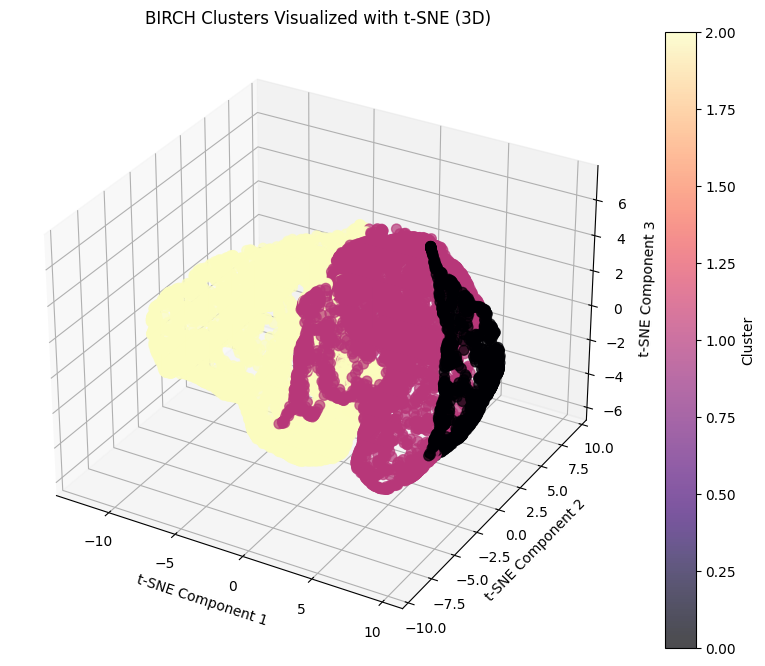

In [18]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=3, perplexity=30, n_iter=300, random_state=42)
X_tsne_3d = tsne.fit_transform(X.drop(columns=['BIRCH_Cluster'], errors='ignore'))

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(X_tsne_3d[:, 0], X_tsne_3d[:, 1], 
                     X_tsne_3d[:, 2], c=labels, cmap='magma', s=50, alpha=0.7)

ax.set_title("BIRCH Clusters Visualized with t-SNE (3D)")
ax.set_xlabel("t-SNE Component 1")
ax.set_ylabel("t-SNE Component 2")
ax.set_zlabel("t-SNE Component 3")
fig.colorbar(scatter, label='Cluster')
plt.show()

<Figure size 1000x800 with 0 Axes>

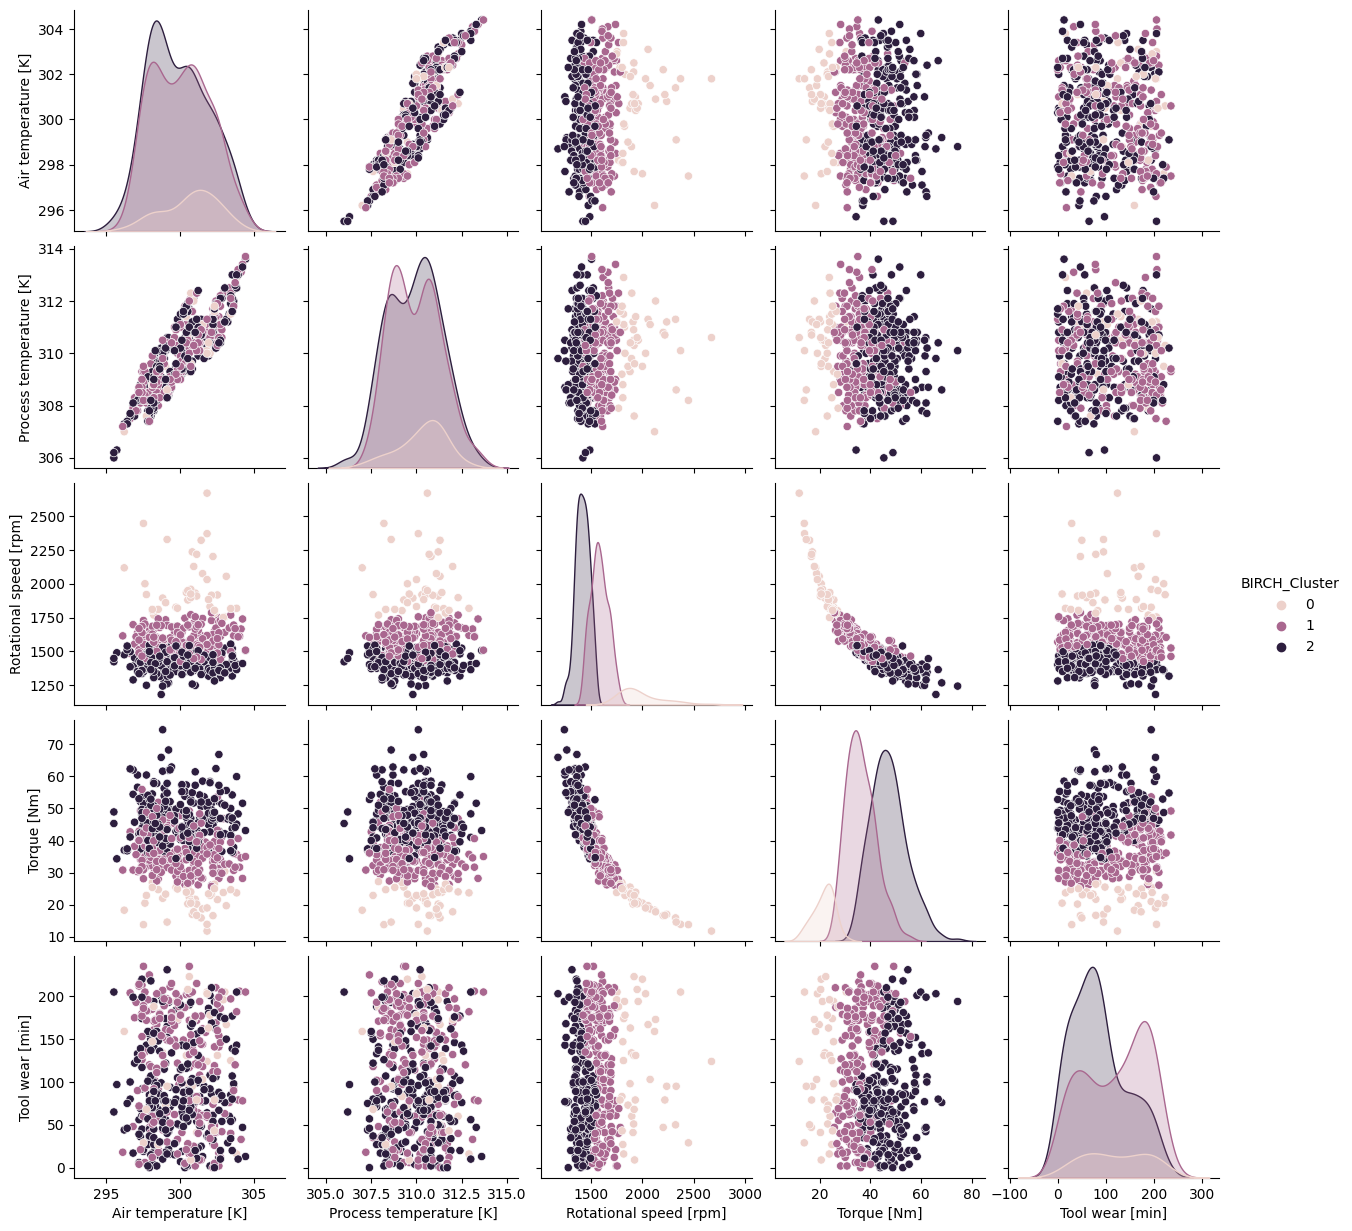

In [19]:
plt.figure(figsize=(10, 8))

sns.pairplot(X.sample(frac=0.05), hue="BIRCH_Cluster", vars=["Air temperature [K]", "Process temperature [K]", "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]"])
plt.show()